# Cubify CNN Training with Synthetic Parcel Data

## Submission-Ready Notebook

This notebook shows a complete, practical workflow for training a **convolutional neural network (CNN)** for the **Cubify** project using the synthetic parcel dataset generated earlier in the project.

The notebook is designed for the **visual dimensioning** part of the Cubify pipeline. In other words, it focuses on the step that predicts **parcel dimensions** from image data. Those predicted dimensions can later be passed into the **directed put-away / 3D bin packing** logic that recommends the best storage location in the warehouse.

---

## Why this notebook matters for Cubify

Cubify aims to replace slow, manual warehouse dimensioning with a camera-based AI workflow that can:

- estimate parcel dimensions automatically
- reduce measurement time from minutes to seconds
- improve consistency and repeatability
- feed downstream optimization logic for storage assignment

This notebook gives you a **baseline, research-friendly training pipeline** that can be used in class submissions, GitHub repositories, and the next phase of your project.

---

## What this notebook covers

1. project framing and assumptions  
2. dataset loading and integrity checks  
3. feature engineering from image + bounding box metadata  
4. a CNN-based multi-input regressor in PyTorch  
5. training, validation, checkpointing, and early stopping  
6. quantitative evaluation with paper-ready metrics  
7. plots and qualitative error inspection  
8. interpretation and next-step recommendations for Cubify

---

## Recommended repository layout

```text
repo_root/
│
├── Cubify_CNN_Training_with_Synthetic_Data.ipynb
└── cubify_data_package/
    └── synthetic/
        ├── train/
        │   └── images/
        ├── val/
        │   └── images/
        └── annotations/
            ├── train_metadata.csv
            ├── val_metadata.csv
            ├── train_coco.json
            └── val_coco.json
```

If your folder structure is different, the notebook includes a path discovery utility that tries to find the dataset automatically.


## Modeling strategy

This notebook uses a **multi-input CNN regressor**:

- **image branch**: learns visual cues from the full parcel image
- **metadata branch**: uses normalized bounding-box information such as width, height, area ratio, and aspect ratio
- **fusion head**: combines both branches to predict **length, width, and height in centimeters**

### Why use both image and bounding-box features?

If we train on a tightly cropped parcel image alone, we lose a lot of the absolute scale information that is relevant for real-world size prediction. For Cubify, scale matters. A model that sees the full image **plus** bounding-box geometry is a more practical baseline for synthetic-data training.

### What this notebook is not

This notebook is **not** the final production model for the full Cubify system. It does **not**:

- solve the directed put-away problem directly
- replace a full object detector such as YOLO
- use real warehouse data
- calibrate depth or camera geometry

Instead, it is a **strong baseline** for the visual regression stage using the currently available synthetic dataset.


In [ ]:
# Optional: uncomment if you need to install missing packages locally
# !pip install torch pandas numpy matplotlib scikit-learn pillow

In [1]:
import json
import math
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageEnhance, ImageFilter

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 1. Reproducibility and configuration

The cell below centralizes the main notebook settings.  
For a **quick smoke test**, set `FAST_DEV_RUN = True`.  
For a **full training run**, keep `FAST_DEV_RUN = False`.


In [2]:
SEED = 42

FAST_DEV_RUN = False  # True = quick smoke test, False = full training
IMAGE_HEIGHT = 128
IMAGE_WIDTH = 192
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
PATIENCE = 5
NUM_WORKERS = 0
BBOX_FEATURE_DIM = 6

if FAST_DEV_RUN:
    EPOCHS = 2
    MAX_TRAIN_SAMPLES = 256
    MAX_VAL_SAMPLES = 128
else:
    EPOCHS = 10
    MAX_TRAIN_SAMPLES = None
    MAX_VAL_SAMPLES = None

OUTPUT_DIR = Path("outputs/cubify_cnn_dimension_regressor")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"FAST_DEV_RUN: {FAST_DEV_RUN}")
print(f"Outputs will be written to: {OUTPUT_DIR.resolve()}")

Using device: cpu
FAST_DEV_RUN: False
Outputs will be written to: C:\AIML\Case Studies\Repo\cubify\outputs\cubify_cnn_dimension_regressor


## 2. Discover the dataset

This helper searches common project locations and, if needed, recursively scans for the required metadata files.


In [3]:
def discover_data_root() -> Path:
    """Find the Cubify synthetic dataset root folder."""

    search_roots = [Path.cwd(), Path.cwd().parent]
    if Path('/mnt/data').exists():
        search_roots.extend([Path('/mnt/data'), Path('/mnt/data/cubify_eda_bundle')])

    candidate_names = [
        "cubify_data_package",
        "data/cubify_data_package",
        "Cubify_Synthetic_EDA_Notebook_and_Data/cubify_data_package",
        "artifacts/cubify_data_package",
    ]

    for root in search_roots:
        for name in candidate_names:
            candidate = root / name
            if (candidate / "synthetic" / "annotations" / "train_metadata.csv").exists():
                return candidate

    for root in search_roots:
        if root.exists():
            for path in root.rglob("train_metadata.csv"):
                if path.name == "train_metadata.csv" and path.parent.name == "annotations":
                    dataset_root = path.parent.parent.parent
                    if (dataset_root / "synthetic" / "annotations" / "val_metadata.csv").exists():
                        return dataset_root

    raise FileNotFoundError(
        "Could not locate cubify_data_package. "
        "Place the notebook near the dataset or update the path logic."
    )

DATA_ROOT = discover_data_root()
DATA_ROOT

WindowsPath('c:/AIML/Case Studies/Repo/cubify/cubify_data_package')

## 3. Load metadata and prepare dataframes

The synthetic dataset already contains:

- image files
- bounding-box metadata
- physical target dimensions in centimeters
- COCO annotation files for future detection work

For this notebook, the **CSV metadata files** are enough to train the regression model.


In [4]:
def load_split_dataframe(data_root: Path, split: str) -> pd.DataFrame:
    metadata_path = data_root / "synthetic" / "annotations" / f"{split}_metadata.csv"
    image_dir = data_root / "synthetic" / split / "images"

    df = pd.read_csv(metadata_path)
    df["split"] = split
    df["image_path"] = df["file_name"].apply(lambda x: str(image_dir / x))
    df["volume_cm3"] = df["length_cm"] * df["width_cm"] * df["height_cm"]
    df["bbox_area_px"] = df["bbox_w"] * df["bbox_h"]
    df["bbox_aspect_ratio"] = df["bbox_w"] / df["bbox_h"].clip(lower=1e-6)
    return df

train_df = load_split_dataframe(DATA_ROOT, "train")
val_df = load_split_dataframe(DATA_ROOT, "val")

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)

train_df.head()

Train shape: (1250, 16)
Val shape: (250, 16)


,image_id,file_name,length_cm,width_cm,height_cm,bbox_x,bbox_y,bbox_w,bbox_h,belt_y,side_sign,split,image_path,volume_cm3,bbox_area_px,bbox_aspect_ratio
0,1,parcel_00001.jpg,85,23,44,111.66,178.17,145.70,66.66,167,-1,train,c:\AIML\Case Studies\Repo\cubify\cubify_data_p...,86020,9712.3620,2.185719
1,2,parcel_00002.jpg,65,24,16,205.40,221.05,115.72,24.23,132,-1,train,c:\AIML\Case Studies\Repo\cubify\cubify_data_p...,24960,2803.8956,4.775898
2,3,parcel_00003.jpg,57,62,55,46.05,162.86,86.99,57.42,156,-1,train,c:\AIML\Case Studies\Repo\cubify\cubify_data_p...,194370,4994.9658,1.514977
3,4,parcel_00004.jpg,37,30,19,265.73,166.96,84.22,34.63,135,1,train,c:\AIML\Case Studies\Repo\cubify\cubify_data_p...,21090,2916.5386,2.431995
4,5,parcel_00005.jpg,65,30,39,50.33,164.05,155.76,81.93,160,1,train,c:\AIML\Case Studies\Repo\cubify\cubify_data_p...,76050,12761.4168,1.901135


## 4. Basic integrity checks

Before training, we verify that:

- the expected columns exist
- image files are reachable
- there are no missing target values
- the target ranges are sensible


In [5]:
required_columns = [
    "file_name", "length_cm", "width_cm", "height_cm",
    "bbox_x", "bbox_y", "bbox_w", "bbox_h", "image_path"
]

missing_in_train = [col for col in required_columns if col not in train_df.columns]
missing_in_val = [col for col in required_columns if col not in val_df.columns]

assert not missing_in_train, f"Missing train columns: {missing_in_train}"
assert not missing_in_val, f"Missing val columns: {missing_in_val}"

assert train_df[["length_cm", "width_cm", "height_cm"]].isna().sum().sum() == 0
assert val_df[["length_cm", "width_cm", "height_cm"]].isna().sum().sum() == 0

train_missing_images = (~train_df["image_path"].map(lambda p: Path(p).exists())).sum()
val_missing_images = (~val_df["image_path"].map(lambda p: Path(p).exists())).sum()

print(f"Missing train images: {train_missing_images}")
print(f"Missing val images: {val_missing_images}")

train_df[["length_cm", "width_cm", "height_cm", "volume_cm3"]].describe()

Missing train images: 0
Missing val images: 0


,length_cm,width_cm,height_cm,volume_cm3
count,1250.000000,1250.000000,1250.000000,1250.000000
mean,55.237600,40.656800,33.848000,76789.937600
std,21.320244,16.685999,14.961363,60968.549349
min,18.000000,12.000000,8.000000,3344.000000
25%,37.000000,26.000000,21.000000,31617.000000
50%,55.000000,40.000000,34.000000,58884.000000
75%,74.000000,55.000000,47.000000,103892.000000
max,90.000000,70.000000,60.000000,335104.000000


## 5. Visual sanity check

This step helps confirm that the data matches our expectations before we invest time in model training.


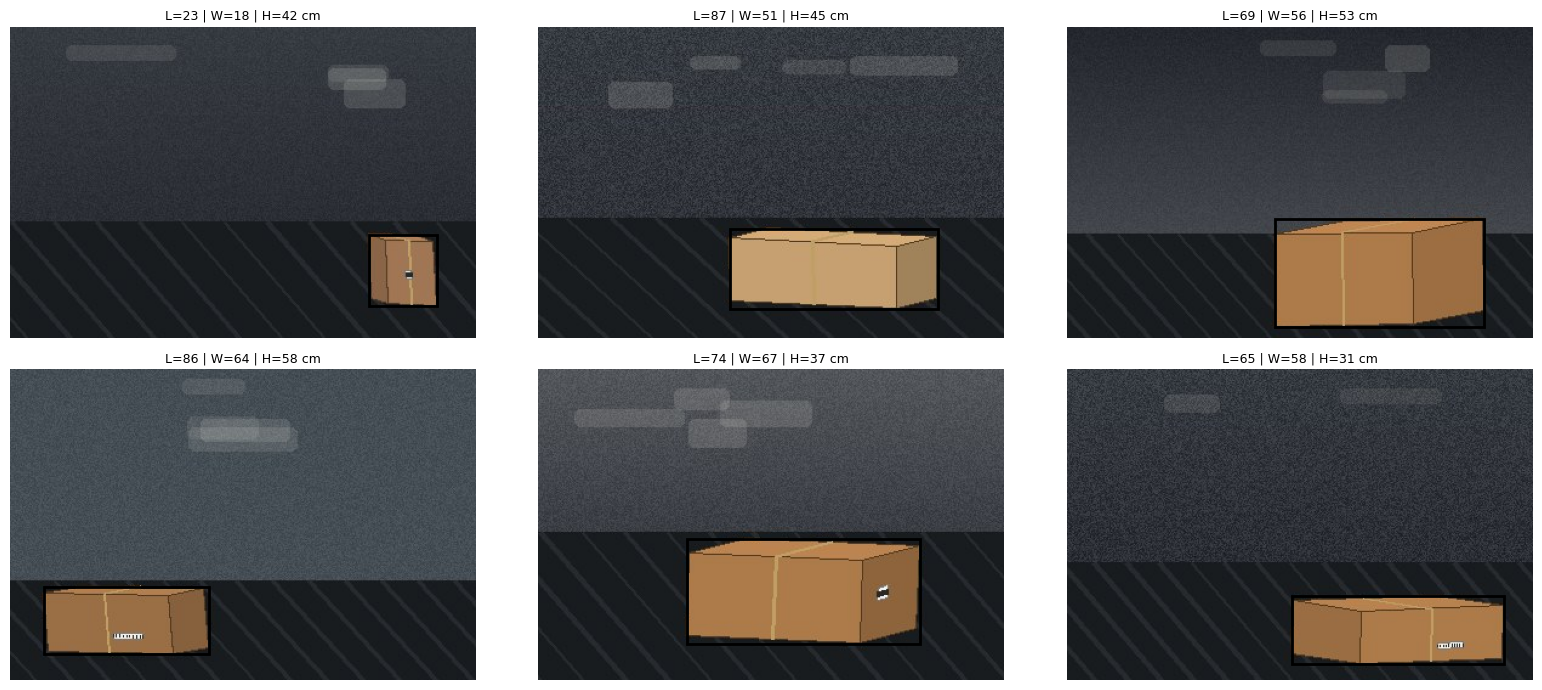

In [6]:
def show_samples(df: pd.DataFrame, n: int = 6) -> None:
    sample_df = df.sample(n=min(n, len(df)), random_state=SEED).reset_index(drop=True)

    fig, axes = plt.subplots(2, math.ceil(len(sample_df) / 2), figsize=(16, 7))
    axes = np.array(axes).reshape(-1)

    for ax, (_, row) in zip(axes, sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)

        rect = plt.Rectangle(
            (row["bbox_x"], row["bbox_y"]),
            row["bbox_w"],
            row["bbox_h"],
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        ax.set_title(
            f"L={row['length_cm']} | W={row['width_cm']} | H={row['height_cm']} cm",
            fontsize=9
        )
        ax.axis("off")

    for ax in axes[len(sample_df):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_df, n=6)

## 6. Target normalization

The model predicts three continuous targets:

- length in cm
- width in cm
- height in cm

We standardize the targets using the **training-set statistics only**.  
This usually stabilizes optimization for regression tasks.


In [7]:
TARGET_COLUMNS = ["length_cm", "width_cm", "height_cm"]

target_mean = train_df[TARGET_COLUMNS].mean().values.astype(np.float32)
target_std = train_df[TARGET_COLUMNS].std().replace(0, 1).values.astype(np.float32)

target_stats = {
    "mean": target_mean.tolist(),
    "std": target_std.tolist(),
}

with open(OUTPUT_DIR / "target_stats.json", "w") as f:
    json.dump(target_stats, f, indent=2)

print("Target mean:", target_mean)
print("Target std:", target_std)

Target mean: [55.2376 40.6568 33.848 ]
Target std: [21.320244 16.685999 14.961363]


## 7. Dataset class

This dataset returns:

- a resized full image tensor
- a compact vector of bounding-box features
- normalized target dimensions

### Bounding-box features used
1. normalized x position  
2. normalized y position  
3. normalized bbox width  
4. normalized bbox height  
5. normalized bbox area ratio  
6. bbox aspect ratio  

These help preserve scale and geometry information that supports physical size prediction.


In [8]:
sample_image = Image.open(train_df.iloc[0]["image_path"]).convert("RGB")
ORIGINAL_WIDTH, ORIGINAL_HEIGHT = sample_image.size
print("Original image size:", (ORIGINAL_WIDTH, ORIGINAL_HEIGHT))


def apply_light_augmentation(img: Image.Image) -> Image.Image:
    if random.random() < 0.5:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.9, 1.1))
    if random.random() < 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.9, 1.1))
    if random.random() < 0.15:
        img = img.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.1, 0.8)))
    return img


class CubifyParcelRegressionDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        image_height: int,
        image_width: int,
        target_mean: np.ndarray,
        target_std: np.ndarray,
        augment: bool = False,
        max_samples: int | None = None,
    ) -> None:
        self.df = df.copy().reset_index(drop=True)
        if max_samples is not None:
            self.df = self.df.sample(n=min(max_samples, len(self.df)), random_state=SEED).reset_index(drop=True)

        self.image_height = image_height
        self.image_width = image_width
        self.target_mean = target_mean.astype(np.float32)
        self.target_std = target_std.astype(np.float32)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB")

        if self.augment:
            img = apply_light_augmentation(img)

        img = img.resize((self.image_width, self.image_height))
        image_array = np.asarray(img, dtype=np.float32) / 255.0
        image_array = np.transpose(image_array, (2, 0, 1))

        bbox_features = np.array([
            row["bbox_x"] / ORIGINAL_WIDTH,
            row["bbox_y"] / ORIGINAL_HEIGHT,
            row["bbox_w"] / ORIGINAL_WIDTH,
            row["bbox_h"] / ORIGINAL_HEIGHT,
            (row["bbox_w"] * row["bbox_h"]) / (ORIGINAL_WIDTH * ORIGINAL_HEIGHT),
            row["bbox_w"] / max(row["bbox_h"], 1e-6),
        ], dtype=np.float32)

        target = row[TARGET_COLUMNS].values.astype(np.float32)
        target = (target - self.target_mean) / self.target_std

        return {
            "image": torch.tensor(image_array, dtype=torch.float32),
            "bbox_features": torch.tensor(bbox_features, dtype=torch.float32),
            "target": torch.tensor(target, dtype=torch.float32),
        }


train_dataset = CubifyParcelRegressionDataset(
    df=train_df,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
    target_mean=target_mean,
    target_std=target_std,
    augment=True,
    max_samples=MAX_TRAIN_SAMPLES,
)

val_dataset = CubifyParcelRegressionDataset(
    df=val_df,
    image_height=IMAGE_HEIGHT,
    image_width=IMAGE_WIDTH,
    target_mean=target_mean,
    target_std=target_std,
    augment=False,
    max_samples=MAX_VAL_SAMPLES,
)

print("Train dataset size:", len(train_dataset))
print("Val dataset size:", len(val_dataset))

sample_batch = next(iter(DataLoader(train_dataset, batch_size=4, shuffle=True)))
{k: tuple(v.shape) for k, v in sample_batch.items()}

Original image size: (384, 256)
Train dataset size: 1250
Val dataset size: 250


{'image': (4, 3, 128, 192), 'bbox_features': (4, 6), 'target': (4, 3)}

## 8. Build dataloaders

`num_workers=0` is used by default for portability across environments, especially on Windows and notebook platforms.


In [9]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

len(train_loader), len(val_loader)

(40, 8)

## 9. Define the CNN model

This is a compact, custom CNN that avoids heavy external dependencies and stays easy to explain in a submission.

### Architecture
- convolutional feature extractor for the image
- small MLP for bounding-box features
- fusion head for 3-output regression

This makes the model both practical and interpretable for the current Cubify stage.


In [10]:
class CubifyCNNRegressor(nn.Module):
    def __init__(self, bbox_feature_dim: int = 6, dropout: float = 0.20) -> None:
        super().__init__()

        self.image_backbone = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )

        self.bbox_branch = nn.Sequential(
            nn.Linear(bbox_feature_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )

        self.regression_head = nn.Sequential(
            nn.Linear(256 + 32, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 3),
        )

    def forward(self, image: torch.Tensor, bbox_features: torch.Tensor) -> torch.Tensor:
        image_features = self.image_backbone(image).flatten(1)
        bbox_features = self.bbox_branch(bbox_features)
        fused = torch.cat([image_features, bbox_features], dim=1)
        return self.regression_head(fused)


model = CubifyCNNRegressor(bbox_feature_dim=BBOX_FEATURE_DIM).to(DEVICE)
model

CubifyCNNRegressor(
  (image_backbone): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, m

## 10. Loss, optimizer, and utility functions

We use:

- **Huber loss** for stable regression
- **AdamW** optimizer
- **ReduceLROnPlateau** scheduler
- **early stopping** to reduce overfitting risk


In [11]:
loss_fn = nn.HuberLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
)


def denormalize_targets(y: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(target_mean, dtype=torch.float32, device=y.device)
    std = torch.tensor(target_std, dtype=torch.float32, device=y.device)
    return y * std + mean


def compute_epoch_metrics(y_true_cm: np.ndarray, y_pred_cm: np.ndarray) -> dict[str, float]:
    metrics = {}

    for i, name in enumerate(["length", "width", "height"]):
        metrics[f"{name}_mae_cm"] = float(mean_absolute_error(y_true_cm[:, i], y_pred_cm[:, i]))
        metrics[f"{name}_rmse_cm"] = float(math.sqrt(mean_squared_error(y_true_cm[:, i], y_pred_cm[:, i])))
        denom = np.clip(np.abs(y_true_cm[:, i]), 1e-6, None)
        metrics[f"{name}_mape_percent"] = float(np.mean(np.abs((y_true_cm[:, i] - y_pred_cm[:, i]) / denom)) * 100.0)
        metrics[f"{name}_r2"] = float(r2_score(y_true_cm[:, i], y_pred_cm[:, i]))

    metrics["mean_mae_cm"] = float(np.mean([
        metrics["length_mae_cm"],
        metrics["width_mae_cm"],
        metrics["height_mae_cm"],
    ]))

    true_volume = np.prod(y_true_cm, axis=1)
    pred_volume = np.prod(y_pred_cm, axis=1)
    volume_denom = np.clip(np.abs(true_volume), 1e-6, None)

    metrics["volume_mae_cm3"] = float(mean_absolute_error(true_volume, pred_volume))
    metrics["volume_mape_percent"] = float(np.mean(np.abs((true_volume - pred_volume) / volume_denom)) * 100.0)

    return metrics

## 11. Training and evaluation loops

These functions keep the training section clean and easier to explain in a report or presentation.


In [12]:
def train_one_epoch(model, loader, optimizer, loss_fn, device):
    model.train()
    running_loss = 0.0

    for batch in loader:
        images = batch["image"].to(device)
        bbox_features = batch["bbox_features"].to(device)
        targets = batch["target"].to(device)

        optimizer.zero_grad()
        outputs = model(images, bbox_features)
        loss = loss_fn(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


@torch.no_grad()
def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss = 0.0

    all_targets = []
    all_predictions = []

    for batch in loader:
        images = batch["image"].to(device)
        bbox_features = batch["bbox_features"].to(device)
        targets = batch["target"].to(device)

        outputs = model(images, bbox_features)
        loss = loss_fn(outputs, targets)

        running_loss += loss.item() * images.size(0)

        targets_cm = denormalize_targets(targets).cpu().numpy()
        preds_cm = denormalize_targets(outputs).cpu().numpy()

        all_targets.append(targets_cm)
        all_predictions.append(preds_cm)

    epoch_loss = running_loss / len(loader.dataset)
    y_true_cm = np.concatenate(all_targets, axis=0)
    y_pred_cm = np.concatenate(all_predictions, axis=0)

    metrics = compute_epoch_metrics(y_true_cm, y_pred_cm)
    metrics["loss"] = float(epoch_loss)

    return metrics, y_true_cm, y_pred_cm

## 12. Train the model

This is the main training block.

### Saved artifacts
- `best_model.pt`
- `history.csv`
- `target_stats.json`
- `validation_predictions.csv`
- `validation_metrics.json`

If you want a faster first pass, set `FAST_DEV_RUN = True` in the configuration cell.


In [13]:
history = []
best_val_loss = float("inf")
best_epoch = -1
epochs_without_improvement = 0
best_model_path = OUTPUT_DIR / "best_model.pt"

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    val_metrics, y_true_val_cm, y_pred_val_cm = evaluate(model, val_loader, loss_fn, DEVICE)

    scheduler.step(val_metrics["loss"])

    current_lr = optimizer.param_groups[0]["lr"]
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_mean_mae_cm": val_metrics["mean_mae_cm"],
        "val_length_mae_cm": val_metrics["length_mae_cm"],
        "val_width_mae_cm": val_metrics["width_mae_cm"],
        "val_height_mae_cm": val_metrics["height_mae_cm"],
        "val_volume_mape_percent": val_metrics["volume_mape_percent"],
        "learning_rate": current_lr,
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_mean_mae_cm={val_metrics['mean_mae_cm']:.3f} | "
        f"lr={current_lr:.6f}"
    )

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_metrics": val_metrics,
                "target_mean": target_mean,
                "target_std": target_std,
                "image_height": IMAGE_HEIGHT,
                "image_width": IMAGE_WIDTH,
            },
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

training_minutes = (time.time() - start_time) / 60.0
history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "history.csv", index=False)

print(f"Best epoch: {best_epoch}")
print(f"Training time: {training_minutes:.2f} minutes")
history_df.tail()

Epoch 01/10 | train_loss=0.3639 | val_loss=0.4154 | val_mean_mae_cm=14.201 | lr=0.001000
Epoch 02/10 | train_loss=0.2530 | val_loss=0.2565 | val_mean_mae_cm=10.342 | lr=0.001000
Epoch 03/10 | train_loss=0.2427 | val_loss=0.2508 | val_mean_mae_cm=10.184 | lr=0.001000
Epoch 04/10 | train_loss=0.2355 | val_loss=0.2927 | val_mean_mae_cm=11.044 | lr=0.001000
Epoch 05/10 | train_loss=0.2365 | val_loss=0.2336 | val_mean_mae_cm=9.764 | lr=0.001000
Epoch 06/10 | train_loss=0.2352 | val_loss=0.2433 | val_mean_mae_cm=10.047 | lr=0.001000
Epoch 07/10 | train_loss=0.2302 | val_loss=0.2319 | val_mean_mae_cm=9.739 | lr=0.001000
Epoch 08/10 | train_loss=0.2259 | val_loss=0.2644 | val_mean_mae_cm=10.494 | lr=0.001000
Epoch 09/10 | train_loss=0.2253 | val_loss=0.2638 | val_mean_mae_cm=10.321 | lr=0.001000
Epoch 10/10 | train_loss=0.2207 | val_loss=0.2325 | val_mean_mae_cm=9.659 | lr=0.000500
Best epoch: 7
Training time: 5.11 minutes


,epoch,train_loss,val_loss,val_mean_mae_cm,val_length_mae_cm,val_width_mae_cm,val_height_mae_cm,val_volume_mape_percent,learning_rate
5,6,0.235151,0.243338,10.046835,10.118997,13.643285,6.378224,64.786705,0.0010
6,7,0.230184,0.231947,9.738558,10.054564,13.604369,5.556742,54.553413,0.0010
7,8,0.225922,0.264444,10.494285,12.182651,13.665408,5.634796,41.117126,0.0010
8,9,0.225276,0.263840,10.321078,10.123408,13.928587,6.911237,42.090572,0.0010
9,10,0.220731,0.232537,9.659143,9.629486,13.443315,5.904628,46.247921,0.0005


## 13. Reload the best checkpoint and evaluate on validation data

This ensures the reported metrics come from the best-performing epoch instead of simply the last epoch.


In [23]:
best_model_path = "outputs/cubify_cnn_dimension_regressor/best_model.pt"
checkpoint = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])

best_val_metrics, y_true_val_cm, y_pred_val_cm = evaluate(model, val_loader, loss_fn, DEVICE)

with open(OUTPUT_DIR / "validation_metrics.json", "w") as f:
    json.dump(best_val_metrics, f, indent=2)

metrics_df = pd.DataFrame([best_val_metrics]).T.rename(columns={0: "value"})
metrics_df

,value
length_mae_cm,10.054564
length_rmse_cm,12.497677
length_mape_percent,20.301394
length_r2,0.671049
width_mae_cm,13.604369
width_rmse_cm,16.037051
width_mape_percent,44.751610
width_r2,0.080103
height_mae_cm,5.556742
height_rmse_cm,6.904028


## 14. Export row-level validation predictions

This file is helpful for later paper analysis, residual studies, and error inspection.


In [24]:
val_export_df = val_dataset.df.copy().reset_index(drop=True)

val_export_df["pred_length_cm"] = y_pred_val_cm[:, 0]
val_export_df["pred_width_cm"] = y_pred_val_cm[:, 1]
val_export_df["pred_height_cm"] = y_pred_val_cm[:, 2]

val_export_df["abs_error_length_cm"] = np.abs(val_export_df["length_cm"] - val_export_df["pred_length_cm"])
val_export_df["abs_error_width_cm"] = np.abs(val_export_df["width_cm"] - val_export_df["pred_width_cm"])
val_export_df["abs_error_height_cm"] = np.abs(val_export_df["height_cm"] - val_export_df["pred_height_cm"])

val_export_df["true_volume_cm3"] = (
    val_export_df["length_cm"] * val_export_df["width_cm"] * val_export_df["height_cm"]
)
val_export_df["pred_volume_cm3"] = (
    val_export_df["pred_length_cm"] * val_export_df["pred_width_cm"] * val_export_df["pred_height_cm"]
)
val_export_df["abs_error_volume_cm3"] = np.abs(
    val_export_df["true_volume_cm3"] - val_export_df["pred_volume_cm3"]
)

val_export_df.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
val_export_df.head()

,image_id,file_name,length_cm,width_cm,height_cm,bbox_x,bbox_y,bbox_w,bbox_h,belt_y,...,bbox_aspect_ratio,pred_length_cm,pred_width_cm,pred_height_cm,abs_error_length_cm,abs_error_width_cm,abs_error_height_cm,true_volume_cm3,pred_volume_cm3,abs_error_volume_cm3
0,1251,parcel_01251.jpg,79,34,45,63.43,168.09,184.06,74.25,164,...,2.478923,74.896988,47.807930,46.381348,4.103012,13.807930,1.381348,120870,166076.296875,45206.296875
1,1252,parcel_01252.jpg,27,61,49,64.52,167.93,110.26,75.65,157,...,1.457502,41.505577,38.021400,50.511307,14.505577,22.978600,1.511307,80703,79711.906250,991.093750
2,1253,parcel_01253.jpg,38,15,14,24.91,167.35,50.66,12.29,150,...,4.122050,34.393257,33.928604,14.521984,3.606743,18.928604,0.521984,7980,16945.923828,8965.923828
3,1254,parcel_01254.jpg,75,13,19,175.53,197.71,123.59,29.22,133,...,4.229637,68.279327,43.153812,22.169151,6.720673,30.153812,3.169151,18525,65321.695312,46796.695312
4,1255,parcel_01255.jpg,76,50,44,129.67,163.90,138.27,60.15,142,...,2.298753,61.794651,43.823341,42.756405,14.205349,6.176659,1.243595,167200,115786.398438,51413.601562


## 15. Plot learning curves

These plots are useful in a submission because they show whether the model improved consistently and whether overfitting is visible.


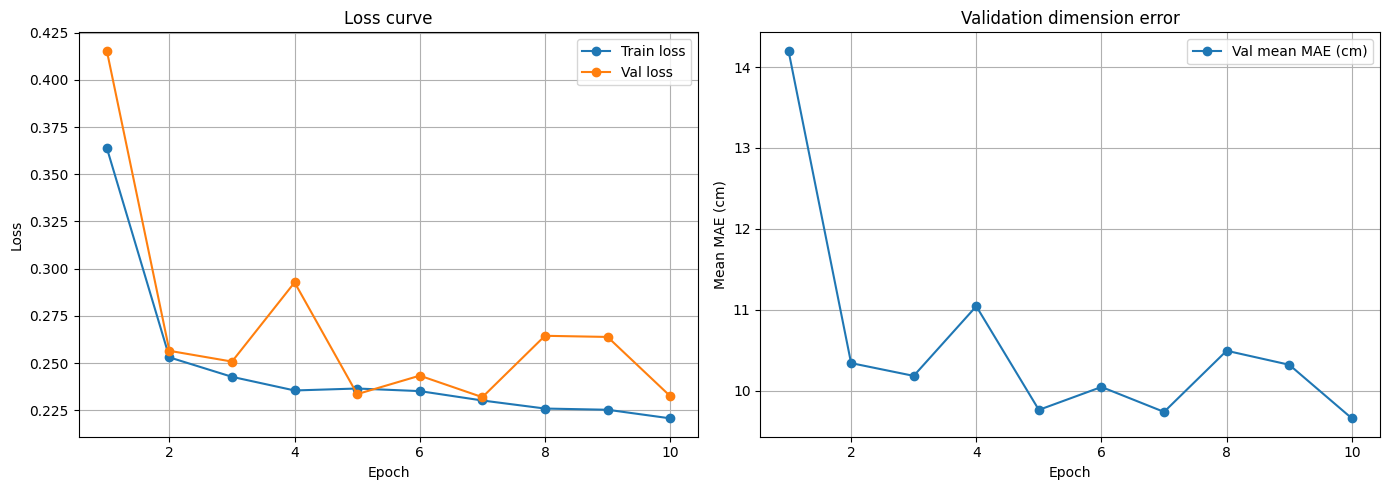

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train loss")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val loss")
axes[0].set_title("Loss curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["val_mean_mae_cm"], marker="o", label="Val mean MAE (cm)")
axes[1].set_title("Validation dimension error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean MAE (cm)")
axes[1].legend()

plt.tight_layout()
plt.show()

## 16. Predicted vs actual plots

A good validation plot should cluster around the diagonal line.  
Large deviations show where the current baseline still struggles.


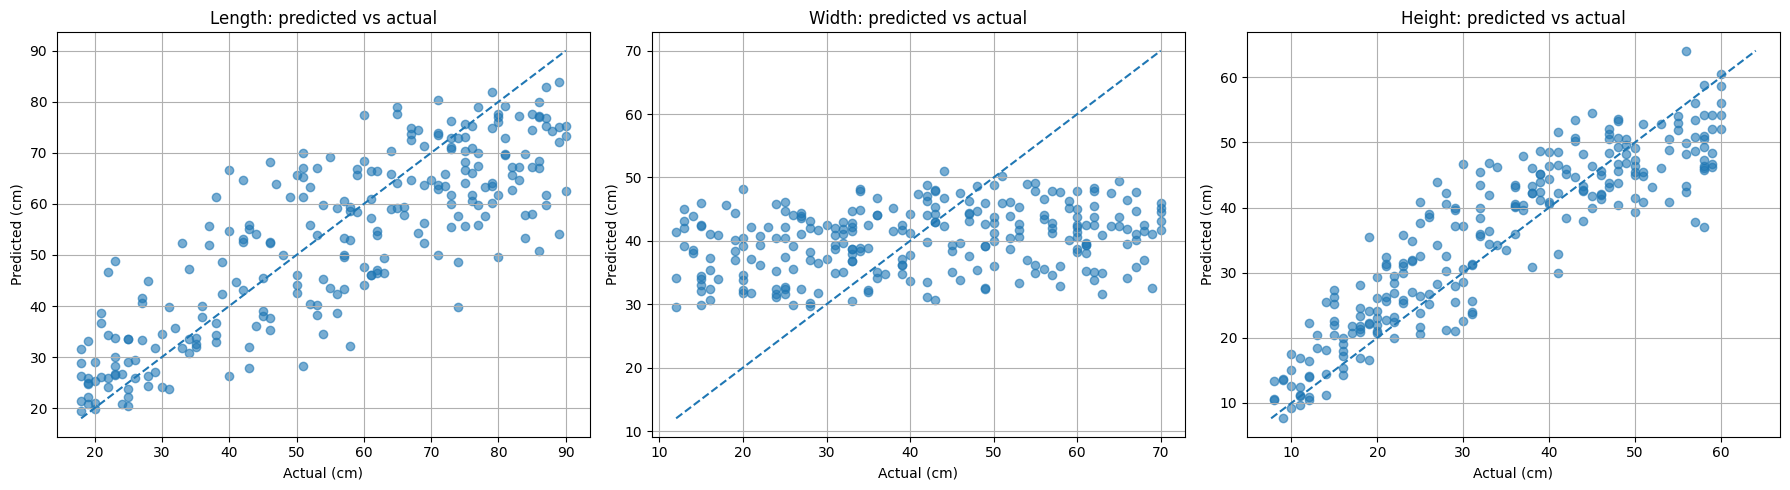

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dimension_names = ["Length", "Width", "Height"]

for i, ax in enumerate(axes):
    ax.scatter(y_true_val_cm[:, i], y_pred_val_cm[:, i], alpha=0.6)
    min_val = min(y_true_val_cm[:, i].min(), y_pred_val_cm[:, i].min())
    max_val = max(y_true_val_cm[:, i].max(), y_pred_val_cm[:, i].max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax.set_title(f"{dimension_names[i]}: predicted vs actual")
    ax.set_xlabel("Actual (cm)")
    ax.set_ylabel("Predicted (cm)")

plt.tight_layout()
plt.show()

## 17. Residual analysis

Residual plots help identify whether the model behaves differently across small vs large parcels.


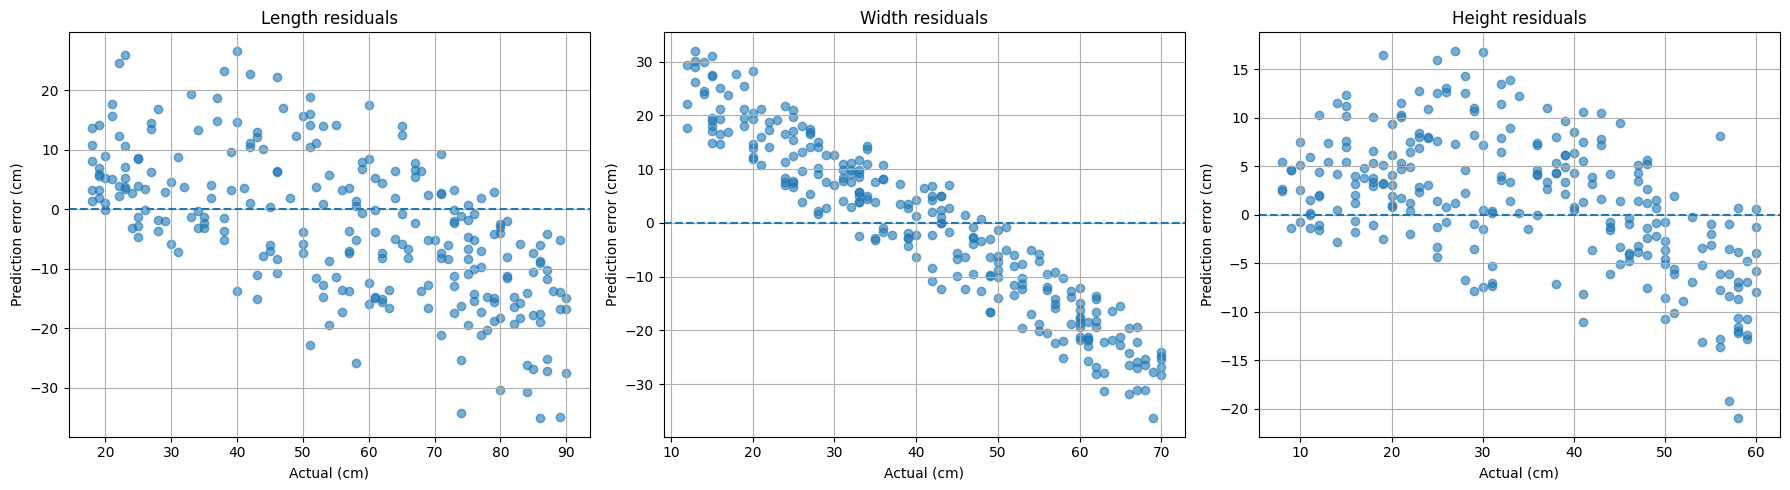

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
dimension_names = ["Length", "Width", "Height"]

for i, ax in enumerate(axes):
    residuals = y_pred_val_cm[:, i] - y_true_val_cm[:, i]
    ax.scatter(y_true_val_cm[:, i], residuals, alpha=0.6)
    ax.axhline(0.0, linestyle="--")
    ax.set_title(f"{dimension_names[i]} residuals")
    ax.set_xlabel("Actual (cm)")
    ax.set_ylabel("Prediction error (cm)")

plt.tight_layout()
plt.show()

## 18. Inspect best and worst validation examples

This is useful for qualitative analysis in your paper or presentation.


In [28]:
val_export_df["mean_abs_dim_error_cm"] = val_export_df[
    ["abs_error_length_cm", "abs_error_width_cm", "abs_error_height_cm"]
].mean(axis=1)

best_examples = val_export_df.nsmallest(3, "mean_abs_dim_error_cm")
worst_examples = val_export_df.nlargest(3, "mean_abs_dim_error_cm")

display(best_examples[[
    "file_name", "length_cm", "width_cm", "height_cm",
    "pred_length_cm", "pred_width_cm", "pred_height_cm",
    "mean_abs_dim_error_cm"
]])

display(worst_examples[[
    "file_name", "length_cm", "width_cm", "height_cm",
    "pred_length_cm", "pred_width_cm", "pred_height_cm",
    "mean_abs_dim_error_cm"
]])

,file_name,length_cm,width_cm,height_cm,pred_length_cm,pred_width_cm,pred_height_cm,mean_abs_dim_error_cm
212,parcel_01463.jpg,58,43,25,59.448238,43.039204,26.387827,0.958423
161,parcel_01412.jpg,20,28,47,21.082321,30.172508,48.384720,1.546516
10,parcel_01261.jpg,73,46,38,72.885704,47.475109,42.271278,1.953561


,file_name,length_cm,width_cm,height_cm,pred_length_cm,pred_width_cm,pred_height_cm,mean_abs_dim_error_cm
147,parcel_01398.jpg,74,68,58,57.680241,42.572540,37.033875,20.904448
83,parcel_01334.jpg,84,12,48,53.234329,41.429672,46.622086,20.524419
182,parcel_01433.jpg,86,63,48,50.840305,40.848705,43.806778,20.501404


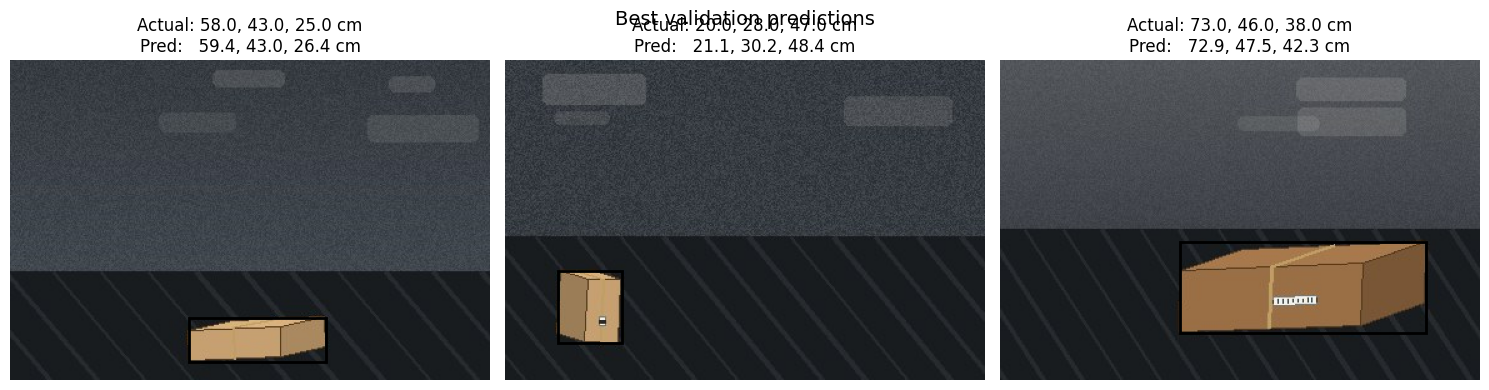

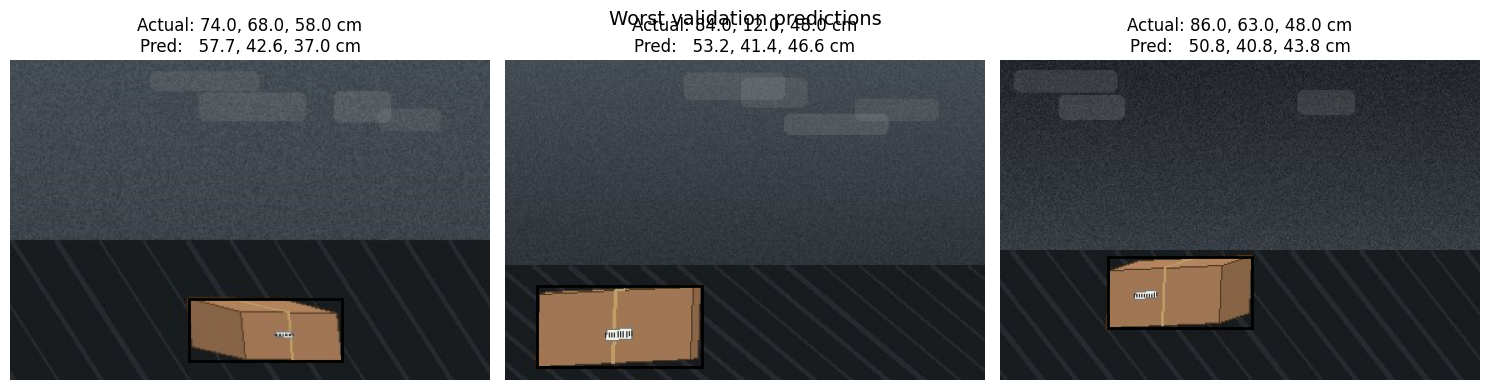

In [29]:
def plot_prediction_examples(example_df: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, len(example_df), figsize=(5 * len(example_df), 4))
    if len(example_df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, example_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        ax.imshow(img)

        rect = plt.Rectangle(
            (row["bbox_x"], row["bbox_y"]),
            row["bbox_w"],
            row["bbox_h"],
            fill=False,
            linewidth=2
        )
        ax.add_patch(rect)

        ax.set_title(
            "Actual: "
            f"{row['length_cm']:.1f}, {row['width_cm']:.1f}, {row['height_cm']:.1f} cm\n"
            "Pred:   "
            f"{row['pred_length_cm']:.1f}, {row['pred_width_cm']:.1f}, {row['pred_height_cm']:.1f} cm"
        )
        ax.axis("off")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

plot_prediction_examples(best_examples, "Best validation predictions")
plot_prediction_examples(worst_examples, "Worst validation predictions")

## 19. Paper-ready summary block

This cell automatically creates a short textual summary you can adapt for your report.


In [30]:
from IPython.display import Markdown, display

summary_md = f'''
### Cubify CNN training summary

Using the synthetic Cubify parcel dataset, the CNN-based regression pipeline achieved:

- **Mean validation MAE:** {best_val_metrics["mean_mae_cm"]:.3f} cm  
- **Length MAE:** {best_val_metrics["length_mae_cm"]:.3f} cm  
- **Width MAE:** {best_val_metrics["width_mae_cm"]:.3f} cm  
- **Height MAE:** {best_val_metrics["height_mae_cm"]:.3f} cm  
- **Volume MAPE:** {best_val_metrics["volume_mape_percent"]:.2f}%  

### Interpretation
This baseline demonstrates that synthetic parcel imagery can support a CNN-based dimensioning model for the Cubify visual measurement stage.  
The model is not yet the final production system, but it provides a valid proof-of-concept for learning dimension-related signals from image data and bounding-box geometry.

### What this means for Cubify
If this visual model is later combined with a directed put-away optimizer, the full pipeline can support:
- faster parcel handling
- more standardized dimensional data
- better downstream storage decisions
- a cleaner path toward warehouse density improvements
'''
display(Markdown(summary_md))


### Cubify CNN training summary

Using the synthetic Cubify parcel dataset, the CNN-based regression pipeline achieved:

- **Mean validation MAE:** 9.739 cm  
- **Length MAE:** 10.055 cm  
- **Width MAE:** 13.604 cm  
- **Height MAE:** 5.557 cm  
- **Volume MAPE:** 54.55%  

### Interpretation
This baseline demonstrates that synthetic parcel imagery can support a CNN-based dimensioning model for the Cubify visual measurement stage.  
The model is not yet the final production system, but it provides a valid proof-of-concept for learning dimension-related signals from image data and bounding-box geometry.

### What this means for Cubify
If this visual model is later combined with a directed put-away optimizer, the full pipeline can support:
- faster parcel handling
- more standardized dimensional data
- better downstream storage decisions
- a cleaner path toward warehouse density improvements


## 20. Recommended next steps for Cubify

### Immediate next steps
1. run this notebook in **full mode** and save the reported metrics  
2. compare the CNN against at least one simpler baseline  
3. move from synthetic-only evaluation to synthetic-plus-real fine-tuning  
4. integrate the predicted dimensions into the storage recommendation logic  

### Model improvements to try next
- deeper CNN backbone
- multi-task learning with auxiliary bbox prediction
- camera calibration or depth-based features
- stronger synthetic augmentations
- detection + regression pipeline instead of metadata-assisted regression

### Project-level next step
This notebook trains the **dimensioning model only**.  
The next Cubify notebook should connect the predicted parcel dimensions into a **storage optimization module** for directed put-away.


## 21. Final notes

This notebook is intentionally built as a **clean, explainable baseline**:

- it is simple enough to defend academically
- it is structured enough for GitHub or submission use
- it is practical enough to extend into the next Cubify stage

For the current project phase, that makes it a strong foundation.
